# Model Benchmarking — CICIoT2023 Network Intrusion Detection

Train and tune 8 classifiers (RF, LightGBM, CatBoost, XGBoost, MLP, 1D-CNN, LSTM, Transformer) with Optuna hyperparameter optimization. Compare on 4-class classification: Benign, BruteForce, Recon, Spoofing.

In [1]:
%matplotlib inline
import glob
import os
import time
import warnings

import pyarrow 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/home/dsalhmd/Documents/uni/level9/gp/smart_home_guard/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 3070


# 1. Load & Preprocess Data

In [2]:
DATA_PATH = "data/ciciot2023_filtered/*.parquet"
parquet_files = glob.glob(DATA_PATH)
df = pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)
df.columns = [c.lower().replace(' ', '_') for c in df.columns]

print(f"Dataset shape: {df.shape}")
print(f"Classes: {df['category'].value_counts().to_dict()}")

Dataset shape: (2208699, 48)
Classes: {'Benign': 1098195, 'Spoofing': 486504, 'Recon': 354565, 'BruteForce': 269435}


In [3]:
X = df.drop(columns=['label', 'category'])
y = df['category']

# 80 / 10 / 10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)
NUM_CLASSES = len(label_encoder.classes_)
NUM_FEATURES = X_train.shape[1]

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]:,}  Val: {X_val_sc.shape[0]:,}  Test: {X_test_sc.shape[0]:,}")
print(f"Features: {NUM_FEATURES}  Classes: {NUM_CLASSES} {list(label_encoder.classes_)}")

Train: 1,766,959  Val: 220,870  Test: 220,870
Features: 46  Classes: 4 ['Benign', 'BruteForce', 'Recon', 'Spoofing']


In [4]:
# PyTorch DataLoaders for deep learning models
BATCH_SIZE = 2048

train_tensor = TensorDataset(
    torch.tensor(X_train_sc, dtype=torch.float32),
    torch.tensor(y_train_enc, dtype=torch.long),
)
val_tensor = TensorDataset(
    torch.tensor(X_val_sc, dtype=torch.float32),
    torch.tensor(y_val_enc, dtype=torch.long),
)
test_tensor = TensorDataset(
    torch.tensor(X_test_sc, dtype=torch.float32),
    torch.tensor(y_test_enc, dtype=torch.long),
)

train_loader = DataLoader(train_tensor, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size=BATCH_SIZE, shuffle=False)

# 2. Helper Functions

In [5]:
# Global results tracker
results = []


def evaluate_model(name, y_train_true, y_train_pred, y_val_true, y_val_pred,
                   y_test_true, y_test_pred, train_time, classes=None):
    """Evaluate a model: print metrics, store results, plot confusion matrix."""
    if classes is None:
        classes = label_encoder.classes_

    train_acc = accuracy_score(y_train_true, y_train_pred)
    val_acc = accuracy_score(y_val_true, y_val_pred)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    val_f1 = f1_score(y_val_true, y_val_pred, average='macro')
    test_f1 = f1_score(y_test_true, y_test_pred, average='macro')
    gap = train_acc - val_acc

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Train Acc: {train_acc:.4f}  |  Val Acc: {val_acc:.4f}  |  Gap: {gap:.4f}")
    print(f"  Val F1 (macro): {val_f1:.4f}  |  Test F1 (macro): {test_f1:.4f}")
    print(f"  Training time: {train_time:.1f}s")

    print(f"\n  Classification Report (Validation):")
    print(classification_report(y_val_true, y_val_pred,
                                target_names=classes, digits=4))
    print(f"  Classification Report (Test):")
    print(classification_report(y_test_true, y_test_pred,
                                target_names=classes, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_val_true, y_val_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'{name} — Confusion Matrix (Validation)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    results.append({
        'Model': name, 'Val F1': val_f1, 'Test F1': test_f1,
        'Train-Val Gap': gap, 'Time (s)': round(train_time, 1)
    })
    return val_f1


def plot_training_curves(train_losses, val_losses, train_accs, val_accs, title):
    """Plot loss and accuracy curves for deep learning models."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(train_losses, label='Train')
    ax1.plot(val_losses, label='Val')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(train_accs, label='Train')
    ax2.plot(val_accs, label='Val')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_pytorch_model(model, train_loader, val_loader, epochs, lr,
                        patience=5, weight_decay=0):
    """Generic training loop with early stopping. Returns history."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct += (out.argmax(1) == y_batch).sum().item()
            total += len(y_batch)

        train_loss = total_loss / total
        train_acc = correct / total

        # Validate
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                out = model(X_batch)
                loss = criterion(out, y_batch)
                total_loss += loss.item() * len(y_batch)
                correct += (out.argmax(1) == y_batch).sum().item()
                total += len(y_batch)

        val_loss = total_loss / total
        val_acc = correct / total
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter >= patience:
            print(f"  Epoch {epoch+1:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    return history


def predict_pytorch(model, loader):
    """Get predictions from a PyTorch model."""
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            out = model(X_batch.to(DEVICE))
            preds.append(out.argmax(1).cpu().numpy())
    return np.concatenate(preds)


print("Helpers ready.")

Helpers ready.


# 3. Random Forest (Baseline)

In [ ]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 10, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
    }
    clf = RandomForestClassifier(**params)
    clf.fit(X_train_sc, y_train_enc)
    preds = clf.predict(X_val_sc)
    return f1_score(y_val_enc, preds, average='macro')

rf_study = optuna.create_study(direction='maximize', study_name='RF')
rf_study.optimize(rf_objective, n_trials=20, show_progress_bar=True)
print(f"Best RF F1: {rf_study.best_value:.4f}")
print(f"Best params: {rf_study.best_params}")

Best trial: 10. Best value: 0.938497:  85%|████████▌ | 17/20 [3:27:37<43:26, 868.84s/it]  


  Random Forest
  Train Acc: 0.9914  |  Val Acc: 0.9419  |  Gap: 0.0495
  Val F1 (macro): 0.9385  |  Test F1 (macro): 0.9401
  Training time: 835.9s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.9375    0.9783    0.9574    109819
  BruteForce     0.9994    0.9785    0.9889     26944
       Recon     0.9195    0.8700    0.8940     35456
    Spoofing     0.9364    0.8920    0.9136     48651

    accuracy                         0.9419    220870
   macro avg     0.9482    0.9297    0.9385    220870
weighted avg     0.9419    0.9419    0.9414    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.9390    0.9790    0.9586    109820
  BruteForce     0.9994    0.9811    0.9901     26943
       Recon     0.9221    0.8725    0.8966     35457
    Spoofing     0.9376    0.8937    0.9151     48650

    accuracy                         0.9434    220870
   macro avg     0

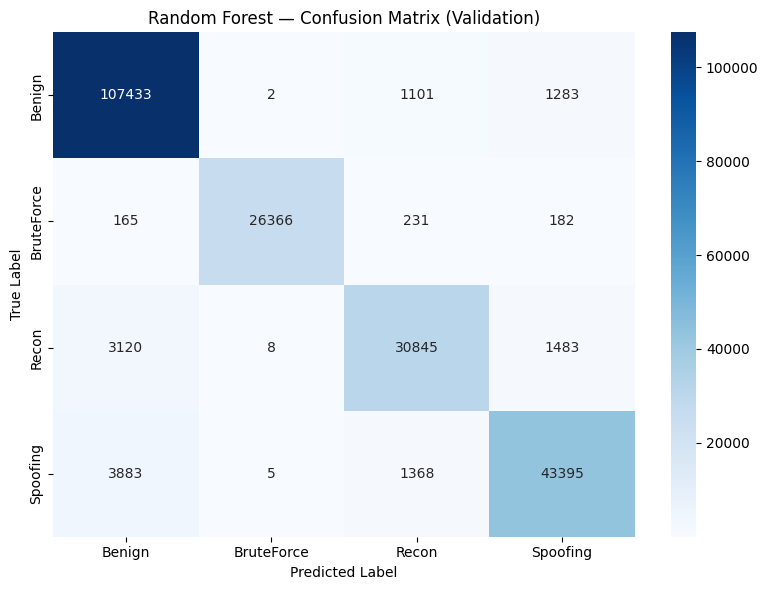

0.9384973034292254

In [7]:
# Retrain best RF
t0 = time.time()
rf_best = RandomForestClassifier(**rf_study.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_sc, y_train_enc)
rf_time = time.time() - t0

evaluate_model(
    'Random Forest',
    y_train_enc, rf_best.predict(X_train_sc),
    y_val_enc, rf_best.predict(X_val_sc),
    y_test_enc, rf_best.predict(X_test_sc),
    rf_time,
)

# 4. LightGBM

In [7]:
def lgb_objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': NUM_CLASSES,
        'metric': 'multi_logloss',
        'verbosity': -1,
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_jobs': -1,
    }
    train_data = lgb.Dataset(X_train_sc, label=y_train_enc)
    val_data = lgb.Dataset(X_val_sc, label=y_val_enc, reference=train_data)

    callbacks = [lgb.early_stopping(stopping_rounds=10)]
    model = lgb.train(params, train_data, num_boost_round=params.pop('n_estimators'),
                      valid_sets=[val_data], valid_names=['valid'], callbacks=callbacks)

    preds = np.argmax(model.predict(X_val_sc), axis=1)
    return f1_score(y_val_enc, preds, average='macro')

lgb_study = optuna.create_study(direction='maximize', study_name='LightGBM')
lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)
print(f"Best LightGBM F1: {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[200]	valid's multi_logloss: 0.154715


Best trial: 0. Best value: 0.936537:   3%|▎         | 1/30 [00:48<23:20, 48.29s/it]

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[608]	valid's multi_logloss: 0.141492


Best trial: 1. Best value: 0.942421:   7%|▋         | 2/30 [02:52<43:25, 93.05s/it]

...

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[600]	valid's multi_logloss: 0.146736


Best trial: 23. Best value: 0.94312:  97%|█████████▋| 29/30 [43:06<01:36, 96.68s/it]

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[53]	valid's multi_logloss: 0.161001


Best trial: 23. Best value: 0.94312: 100%|██████████| 30/30 [43:20<00:00, 86.67s/it]

Best LightGBM F1: 0.9431
Best params: {'num_leaves': 154, 'learning_rate': 0.20900133062832713, 'n_estimators': 700, 'max_depth': 8, 'min_child_samples': 65, 'subsample': 0.6041524940255838, 'colsample_bytree': 0.7714068726610056, 'reg_alpha': 7.531357645875691, 'reg_lambda': 0.000540968611645633}


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[645]	train's multi_logloss: 0.0878504	valid's multi_logloss: 0.139031


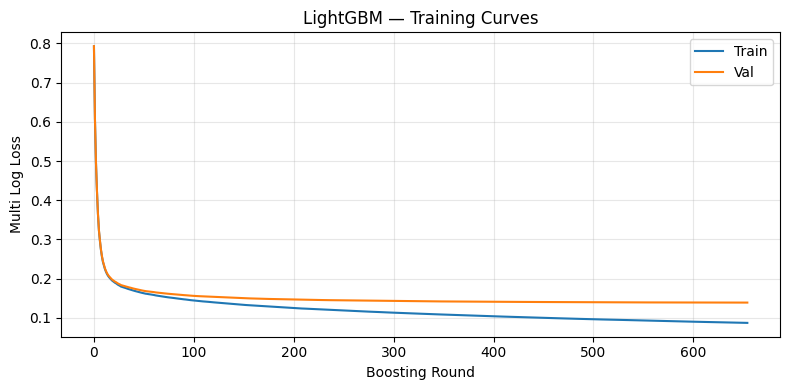


  LightGBM
  Train Acc: 0.9708  |  Val Acc: 0.9462  |  Gap: 0.0246
  Val F1 (macro): 0.9431  |  Test F1 (macro): 0.9437
  Training time: 137.9s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.9448    0.9771    0.9607    109819
  BruteForce     0.9981    0.9799    0.9889     26944
       Recon     0.9228    0.8844    0.9032     35456
    Spoofing     0.9373    0.9027    0.9197     48651

    accuracy                         0.9462    220870
   macro avg     0.9507    0.9360    0.9431    220870
weighted avg     0.9461    0.9462    0.9459    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.9447    0.9779    0.9610    109820
  BruteForce     0.9980    0.9822    0.9901     26943
       Recon     0.9247    0.8856    0.9047     35457
    Spoofing     0.9380    0.9007    0.9189     48650

    accuracy                         0.9466    220870
   macro avg     0.9513

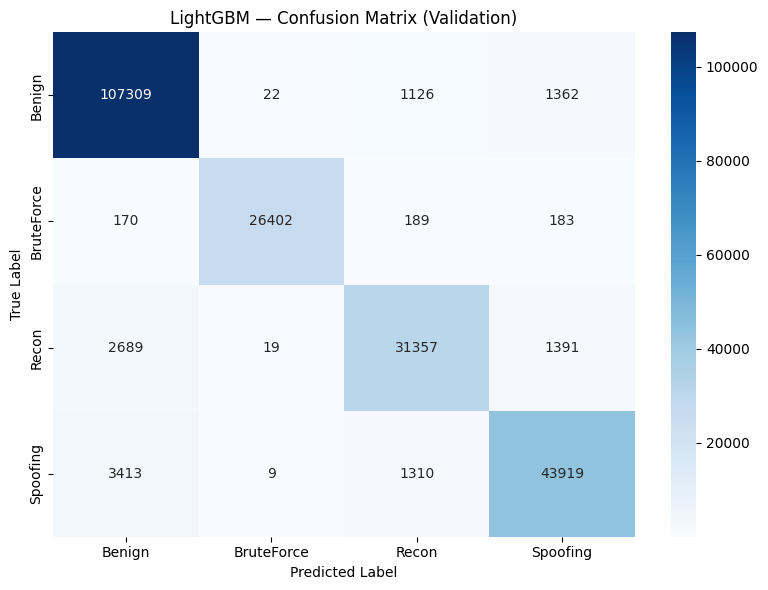

0.9431199094928873

In [8]:
# Retrain best LightGBM with training curves
best_lgb_params = {**lgb_study.best_params,
                   'objective': 'multiclass', 'num_class': NUM_CLASSES,
                   'metric': 'multi_logloss', 'verbosity': -1, 'n_jobs': -1}
n_rounds = best_lgb_params.pop('n_estimators')

train_data = lgb.Dataset(X_train_sc, label=y_train_enc)
val_data = lgb.Dataset(X_val_sc, label=y_val_enc, reference=train_data)
lgb_eval = {}

t0 = time.time()
lgb_best = lgb.train(
    best_lgb_params, train_data, num_boost_round=n_rounds,
    valid_sets=[train_data, val_data], valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(10), lgb.record_evaluation(lgb_eval)]
)
lgb_time = time.time() - t0

# Plot LightGBM curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lgb_eval['train']['multi_logloss'], label='Train')
ax.plot(lgb_eval['valid']['multi_logloss'], label='Val')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Multi Log Loss')
ax.set_title('LightGBM — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_train_pred_lgb = np.argmax(lgb_best.predict(X_train_sc), axis=1)
y_val_pred_lgb = np.argmax(lgb_best.predict(X_val_sc), axis=1)
y_test_pred_lgb = np.argmax(lgb_best.predict(X_test_sc), axis=1)

evaluate_model('LightGBM', y_train_enc, y_train_pred_lgb,
               y_val_enc, y_val_pred_lgb, y_test_enc, y_test_pred_lgb, lgb_time)

# 5. CatBoost (GPU)

In [9]:
def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000, step=100),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'task_type': 'GPU',
        'loss_function': 'MultiClass',
        'eval_metric': 'TotalF1:average=Macro',
        'random_seed': 42,
        'verbose': 0,
    }
    train_pool = Pool(X_train_sc, y_train_enc)
    val_pool = Pool(X_val_sc, y_val_enc)

    clf = CatBoostClassifier(**params)
    clf.fit(train_pool, eval_set=val_pool, early_stopping_rounds=10)
    preds = clf.predict(X_val_sc).flatten().astype(int)
    return f1_score(y_val_enc, preds, average='macro')

cb_study = optuna.create_study(direction='maximize', study_name='CatBoost')
cb_study.optimize(cb_objective, n_trials=25, show_progress_bar=True)
print(f"Best CatBoost F1: {cb_study.best_value:.4f}")
print(f"Best params: {cb_study.best_params}")

Best trial: 21. Best value: 0.936506: 100%|██████████| 25/25 [05:01<00:00, 12.04s/it]

Best CatBoost F1: 0.9365
Best params: {'iterations': 600, 'depth': 9, 'learning_rate': 0.2959517210791656, 'l2_leaf_reg': 1.2532485887504081, 'bagging_temperature': 0.3611455682402859, 'random_strength': 9.963044885953167, 'border_count': 128}


0:	learn: 0.8376981	test: 0.8385007	best: 0.8385007 (0)	total: 28.5ms	remaining: 17.1s
50:	learn: 0.1958398	test: 0.1983726	best: 0.1983726 (50)	total: 1.36s	remaining: 14.7s
100:	learn: 0.1755345	test: 0.1799150	best: 0.1799150 (100)	total: 2.9s	remaining: 14.3s
150:	learn: 0.1651424	test: 0.1717413	best: 0.1717413 (150)	total: 4.47s	remaining: 13.3s
200:	learn: 0.1579698	test: 0.1671238	best: 0.1671238 (200)	total: 6.02s	remaining: 12s
250:	learn: 0.1526646	test: 0.1640838	best: 0.1640838 (250)	total: 7.63s	remaining: 10.6s
300:	learn: 0.1477543	test: 0.1613787	best: 0.1613787 (300)	total: 9.17s	remaining: 9.11s
350:	learn: 0.1437678	test: 0.1589922	best: 0.1589922 (350)	total: 10.7s	remaining: 7.59s
400:	learn: 0.1399248	test: 0.1571293	best: 0.1571293 (400)	total: 12.2s	remaining: 6.08s
450:	learn: 0.1367073	test: 0.1559761	best: 0.1559761 (450)	total: 13.8s	remaining: 4.56s
500:	learn: 0.1335968	test: 0.1550843	best: 0.1550843 (500)	total: 15.3s	remaining: 3.03s
550:	learn: 0.1308

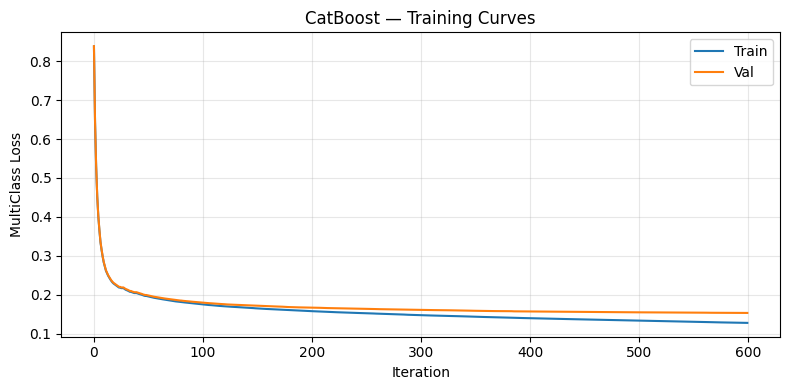


  CatBoost
  Train Acc: 0.9528  |  Val Acc: 0.9406  |  Gap: 0.0121
  Val F1 (macro): 0.9375  |  Test F1 (macro): 0.9381
  Training time: 18.9s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.9355    0.9773    0.9560    109819
  BruteForce     0.9981    0.9784    0.9882     26944
       Recon     0.9212    0.8693    0.8945     35456
    Spoofing     0.9346    0.8890    0.9112     48651

    accuracy                         0.9406    220870
   macro avg     0.9474    0.9285    0.9375    220870
weighted avg     0.9407    0.9406    0.9402    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.9354    0.9779    0.9562    109820
  BruteForce     0.9978    0.9812    0.9894     26943
       Recon     0.9218    0.8694    0.8948     35457
    Spoofing     0.9371    0.8884    0.9121     48650

    accuracy                         0.9412    220870
   macro avg     0.9480 

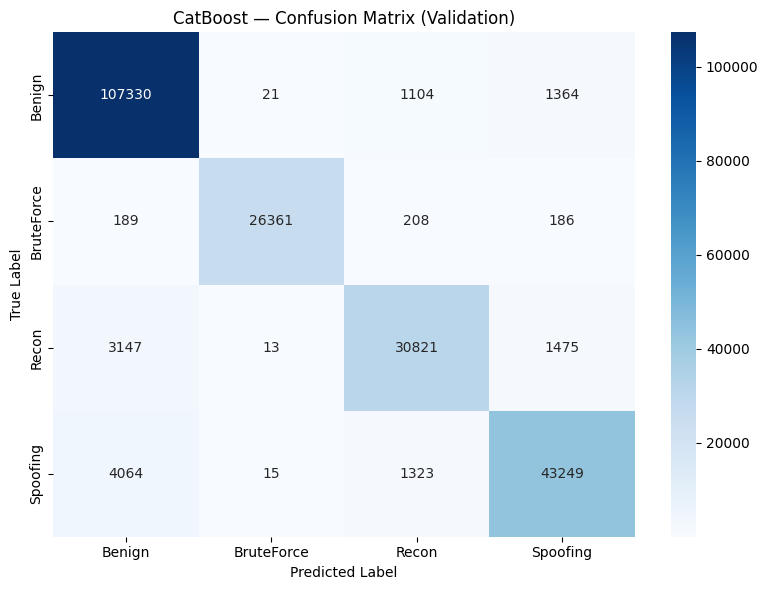

0.937460747489003

In [10]:
# Retrain best CatBoost
best_cb_params = {**cb_study.best_params, 'task_type': 'GPU',
                  'loss_function': 'MultiClass', 'random_seed': 42, 'verbose': 50}
train_pool = Pool(X_train_sc, y_train_enc)
val_pool = Pool(X_val_sc, y_val_enc)

t0 = time.time()
cb_best = CatBoostClassifier(**best_cb_params)
cb_best.fit(train_pool, eval_set=val_pool, early_stopping_rounds=10)
cb_time = time.time() - t0

# Plot CatBoost curves
evals = cb_best.get_evals_result()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(evals['learn']['MultiClass'], label='Train')
ax.plot(evals['validation']['MultiClass'], label='Val')
ax.set_xlabel('Iteration')
ax.set_ylabel('MultiClass Loss')
ax.set_title('CatBoost — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_train_pred_cb = cb_best.predict(X_train_sc).flatten().astype(int)
y_val_pred_cb = cb_best.predict(X_val_sc).flatten().astype(int)
y_test_pred_cb = cb_best.predict(X_test_sc).flatten().astype(int)

evaluate_model('CatBoost', y_train_enc, y_train_pred_cb,
               y_val_enc, y_val_pred_cb, y_test_enc, y_test_pred_cb, cb_time)

# 6. XGBoost (GPU)

In [11]:
def xgb_objective(trial):
    params = {
        'objective': 'multi:softmax',
        'num_class': NUM_CLASSES,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbosity': 0,
    }
    clf = xgb.XGBClassifier(**params, early_stopping_rounds=10)
    clf.fit(X_train_sc, y_train_enc,
            eval_set=[(X_val_sc, y_val_enc)], verbose=False)
    preds = clf.predict(X_val_sc)
    return f1_score(y_val_enc, preds, average='macro')

xgb_study = optuna.create_study(direction='maximize', study_name='XGBoost')
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)
print(f"Best XGBoost F1: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

Best trial: 12. Best value: 0.942533: 100%|██████████| 30/30 [13:39<00:00, 27.31s/it]

Best XGBoost F1: 0.9425
Best params: {'max_depth': 10, 'learning_rate': 0.15932517413822603, 'n_estimators': 500, 'subsample': 0.8680381730518625, 'colsample_bytree': 0.9216761079152825, 'min_child_weight': 1, 'reg_alpha': 2.769411477521907e-06, 'reg_lambda': 0.028747121180108044}


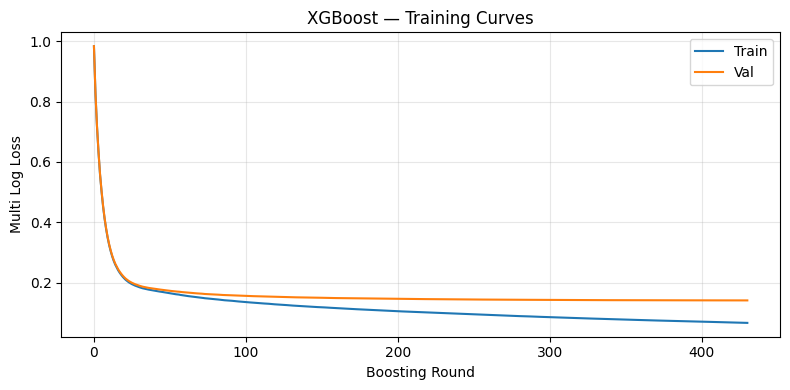


  XGBoost
  Train Acc: 0.9814  |  Val Acc: 0.9455  |  Gap: 0.0360
  Val F1 (macro): 0.9425  |  Test F1 (macro): 0.9429
  Training time: 28.8s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.9417    0.9788    0.9599    109819
  BruteForce     0.9992    0.9798    0.9894     26944
       Recon     0.9264    0.8804    0.9028     35456
    Spoofing     0.9382    0.8988    0.9181     48651

    accuracy                         0.9455    220870
   macro avg     0.9514    0.9344    0.9425    220870
weighted avg     0.9455    0.9455    0.9451    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.9425    0.9792    0.9605    109820
  BruteForce     0.9985    0.9822    0.9903     26943
       Recon     0.9260    0.8809    0.9029     35457
    Spoofing     0.9387    0.8981    0.9180     48650

    accuracy                         0.9459    220870
   macro avg     0.9514  

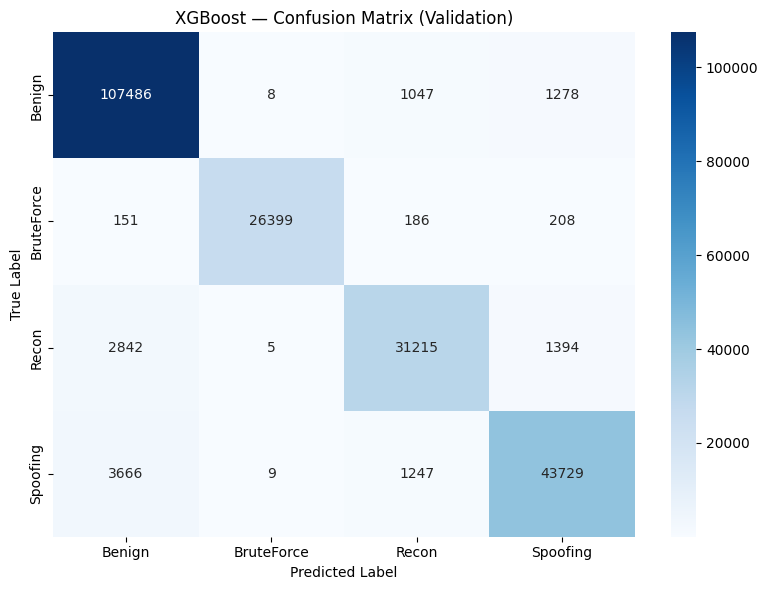

0.9425326217965144

In [12]:
# Retrain best XGBoost
best_xgb_params = {**xgb_study.best_params, 'objective': 'multi:softmax',
                   'num_class': NUM_CLASSES, 'tree_method': 'hist', 'device': 'cuda',
                   'random_state': 42, 'verbosity': 0}

t0 = time.time()
xgb_best = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=10)
xgb_best.fit(X_train_sc, y_train_enc,
             eval_set=[(X_train_sc, y_train_enc), (X_val_sc, y_val_enc)],
             verbose=False)
xgb_time = time.time() - t0

# Plot XGBoost curves
xgb_evals = xgb_best.evals_result()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xgb_evals['validation_0']['mlogloss'], label='Train')
ax.plot(xgb_evals['validation_1']['mlogloss'], label='Val')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Multi Log Loss')
ax.set_title('XGBoost — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

evaluate_model('XGBoost', y_train_enc, xgb_best.predict(X_train_sc),
               y_val_enc, xgb_best.predict(X_val_sc),
               y_test_enc, xgb_best.predict(X_test_sc), xgb_time)

# 7. MLP (PyTorch)

In [13]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def mlp_objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = [trial.suggest_int(f'h{i}', 64, 512, step=64) for i in range(n_layers)]
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    model = TabularMLP(NUM_FEATURES, hidden_dims, NUM_CLASSES, dropout)
    history = train_pytorch_model(model, train_loader, val_loader,
                                  epochs=30, lr=lr, patience=5, weight_decay=wd)
    val_preds = predict_pytorch(model, val_loader)
    return f1_score(y_val_enc, val_preds, average='macro')

mlp_study = optuna.create_study(direction='maximize', study_name='MLP')
mlp_study.optimize(mlp_objective, n_trials=20, show_progress_bar=True)
print(f"Best MLP F1: {mlp_study.best_value:.4f}")
print(f"Best params: {mlp_study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   5  train_loss=0.4438  val_loss=0.4151  val_acc=0.8356
  Epoch  10  train_loss=0.4307  val_loss=0.4026  val_acc=0.8379
  Epoch  15  train_loss=0.4217  val_loss=0.3999  val_acc=0.8418
  Epoch  20  train_loss=0.4204  val_loss=0.3954  val_acc=0.8410
  Epoch  23  train_loss=0.4156  val_loss=0.4027  val_acc=0.8383
  Early stopping at epoch 23


Best trial: 0. Best value: 0.831676:   5%|▌         | 1/20 [04:40<1:28:55, 280.80s/it]

  Epoch   5  train_loss=0.4720  val_loss=0.4486  val_acc=0.8231
  Epoch  10  train_loss=0.4360  val_loss=0.4141  val_acc=0.8345
  Epoch  15  train_loss=0.4159  val_loss=0.3979  val_acc=0.8410
  Epoch  20  train_loss=0.4043  val_loss=0.3853  val_acc=0.8450
  Epoch  25  train_loss=0.3963  val_loss=0.3780  val_acc=0.8488
  Epoch  30  train_loss=0.3896  val_loss=0.3720  val_acc=0.8510


Best trial: 1. Best value: 0.840146:  10%|█         | 2/20 [10:50<1:39:59, 333.33s/it]

...

  Epoch   5  train_loss=0.3983  val_loss=0.3927  val_acc=0.8447
  Epoch  10  train_loss=0.3859  val_loss=0.3700  val_acc=0.8524
  Epoch  15  train_loss=0.3803  val_loss=0.3748  val_acc=0.8516
  Epoch  20  train_loss=0.3781  val_loss=0.3607  val_acc=0.8541
  Epoch  25  train_loss=0.3767  val_loss=0.3747  val_acc=0.8546
  Epoch  30  train_loss=0.3646  val_loss=0.3507  val_acc=0.8610


Best trial: 14. Best value: 0.86256:  95%|█████████▌| 19/20 [2:00:27<06:21, 381.76s/it]

  Epoch   5  train_loss=0.4160  val_loss=0.4001  val_acc=0.8383
  Epoch  10  train_loss=0.3869  val_loss=0.3705  val_acc=0.8497
  Epoch  15  train_loss=0.3703  val_loss=0.3550  val_acc=0.8558
  Epoch  20  train_loss=0.3591  val_loss=0.3452  val_acc=0.8605
  Epoch  25  train_loss=0.3507  val_loss=0.3363  val_acc=0.8640
  Epoch  30  train_loss=0.3448  val_loss=0.3373  val_acc=0.8646


Best trial: 14. Best value: 0.86256: 100%|██████████| 20/20 [2:06:58<00:00, 380.93s/it]

Best MLP F1: 0.8626
Best params: {'n_layers': 3, 'h0': 448, 'h1': 512, 'h2': 64, 'dropout': 0.1050829493359667, 'lr': 0.000566004880124828, 'weight_decay': 1.4571703661443928e-05}


  Epoch   5  train_loss=0.3923  val_loss=0.3730  val_acc=0.8483
  Epoch  10  train_loss=0.3670  val_loss=0.3542  val_acc=0.8561
  Epoch  15  train_loss=0.3549  val_loss=0.3422  val_acc=0.8606
  Epoch  20  train_loss=0.3472  val_loss=0.3349  val_acc=0.8639
  Epoch  25  train_loss=0.3424  val_loss=0.3252  val_acc=0.8682
  Epoch  30  train_loss=0.3309  val_loss=0.3220  val_acc=0.8707
  Epoch  35  train_loss=0.3283  val_loss=0.3190  val_acc=0.8718
  Epoch  37  train_loss=0.3227  val_loss=0.3233  val_acc=0.8705
  Early stopping at epoch 37


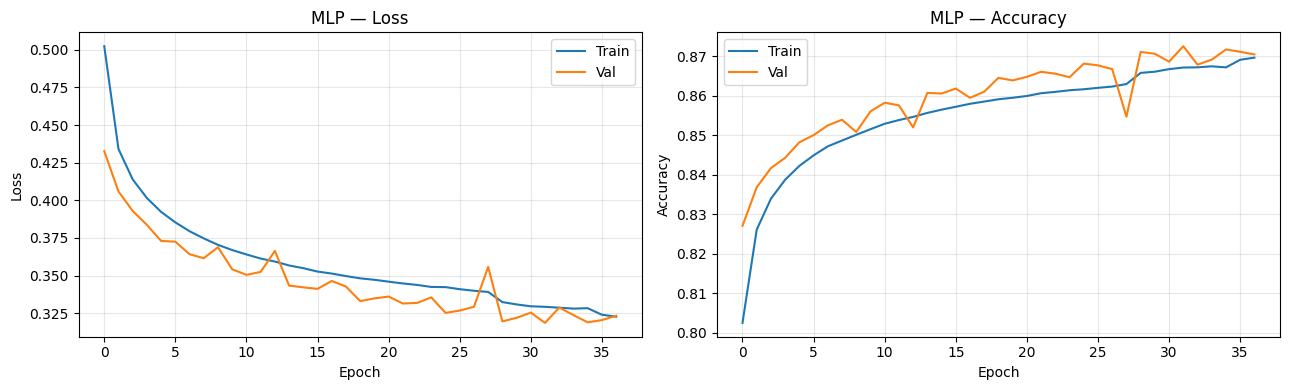


  MLP
  Train Acc: 0.3470  |  Val Acc: 0.8726  |  Gap: -0.5256
  Val F1 (macro): 0.8644  |  Test F1 (macro): 0.8631
  Training time: 477.2s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.8802    0.9385    0.9084    109819
  BruteForce     0.9998    0.9586    0.9787     26944
       Recon     0.7975    0.7412    0.7683     35456
    Spoofing     0.8348    0.7719    0.8021     48651

    accuracy                         0.8726    220870
   macro avg     0.8781    0.8526    0.8644    220870
weighted avg     0.8715    0.8726    0.8711    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.8774    0.9387    0.9070    109820
  BruteForce     0.9998    0.9604    0.9797     26943
       Recon     0.7993    0.7382    0.7675     35457
    Spoofing     0.8331    0.7663    0.7983     48650

    accuracy                         0.8712    220870
   macro avg     0.8774    

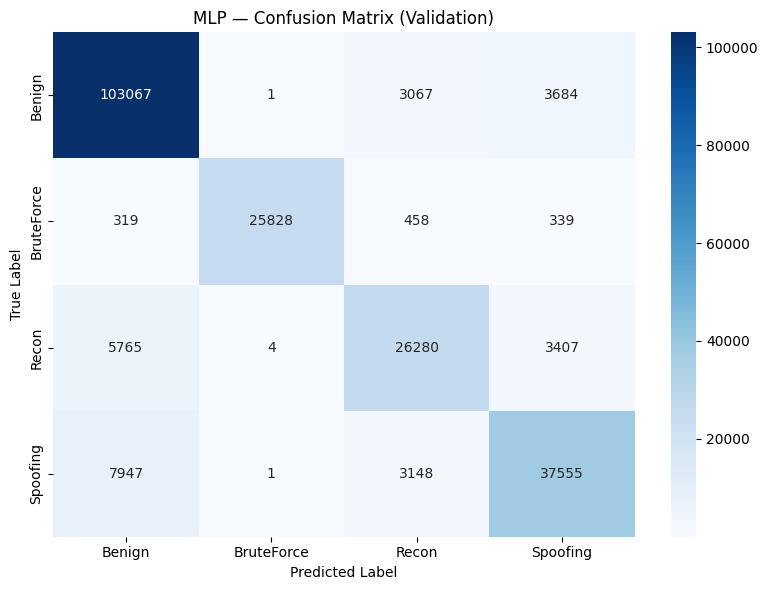

0.8644053229615509

In [14]:
# Retrain best MLP
bp = mlp_study.best_params
hidden_dims = [bp[f'h{i}'] for i in range(bp['n_layers'])]
mlp_best = TabularMLP(NUM_FEATURES, hidden_dims, NUM_CLASSES, bp['dropout'])

t0 = time.time()
mlp_history = train_pytorch_model(mlp_best, train_loader, val_loader,
                                   epochs=50, lr=bp['lr'], patience=5,
                                   weight_decay=bp['weight_decay'])
mlp_time = time.time() - t0

plot_training_curves(mlp_history['train_loss'], mlp_history['val_loss'],
                     mlp_history['train_acc'], mlp_history['val_acc'], 'MLP')

evaluate_model('MLP', y_train_enc, predict_pytorch(mlp_best, train_loader),
               y_val_enc, predict_pytorch(mlp_best, val_loader),
               y_test_enc, predict_pytorch(mlp_best, test_loader), mlp_time)

# 8. 1D-CNN (PyTorch)

In [15]:
class CNN1D(nn.Module):
    """Treats each sample's features as a 1D sequence with 1 input channel."""
    def __init__(self, input_dim, num_classes, n_filters=64, kernel_size=3, dropout=0.3):
        super().__init__()
        # Input: (batch, 1, input_dim)
        self.conv = nn.Sequential(
            nn.Conv1d(1, n_filters, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(n_filters), nn.ReLU(),
            nn.Conv1d(n_filters, n_filters * 2, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(n_filters * 2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(n_filters * 2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        x = self.conv(x).squeeze(-1)
        return self.classifier(x)


def cnn_objective(trial):
    n_filters = trial.suggest_int('n_filters', 32, 128, step=32)
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5, 7])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    model = CNN1D(NUM_FEATURES, NUM_CLASSES, n_filters, kernel_size, dropout)
    train_pytorch_model(model, train_loader, val_loader,
                        epochs=30, lr=lr, patience=5, weight_decay=wd)
    val_preds = predict_pytorch(model, val_loader)
    return f1_score(y_val_enc, val_preds, average='macro')

cnn_study = optuna.create_study(direction='maximize', study_name='1D-CNN')
cnn_study.optimize(cnn_objective, n_trials=20, show_progress_bar=True)
print(f"Best 1D-CNN F1: {cnn_study.best_value:.4f}")
print(f"Best params: {cnn_study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   5  train_loss=0.5009  val_loss=0.4993  val_acc=0.8025
  Epoch  10  train_loss=0.4492  val_loss=0.4307  val_acc=0.8285
  Epoch  15  train_loss=0.4292  val_loss=0.4186  val_acc=0.8337
  Epoch  20  train_loss=0.4229  val_loss=0.4066  val_acc=0.8381
  Epoch  25  train_loss=0.4189  val_loss=0.4040  val_acc=0.8400
  Epoch  30  train_loss=0.4138  val_loss=0.3997  val_acc=0.8409


Best trial: 0. Best value: 0.829169:   5%|▌         | 1/20 [11:02<3:29:46, 662.47s/it]

  Epoch   5  train_loss=0.5687  val_loss=0.5885  val_acc=0.7712
  Epoch  10  train_loss=0.5435  val_loss=0.5364  val_acc=0.7865
  Epoch  15  train_loss=0.5341  val_loss=0.7818  val_acc=0.6999
  Epoch  20  train_loss=0.5282  val_loss=0.5452  val_acc=0.7816
  Epoch  25  train_loss=0.5211  val_loss=0.5304  val_acc=0.7873
  Epoch  26  train_loss=0.5209  val_loss=0.5346  val_acc=0.7851
  Early stopping at epoch 26


Best trial: 0. Best value: 0.829169:  10%|█         | 2/20 [17:19<2:28:22, 494.60s/it]

...

  Epoch   5  train_loss=0.5243  val_loss=0.4824  val_acc=0.8053
  Epoch  10  train_loss=0.4794  val_loss=0.6633  val_acc=0.7227
  Epoch  15  train_loss=0.4534  val_loss=0.4257  val_acc=0.8315
  Epoch  20  train_loss=0.4458  val_loss=0.4185  val_acc=0.8343
  Epoch  25  train_loss=0.4347  val_loss=0.4120  val_acc=0.8361
  Epoch  30  train_loss=0.4290  val_loss=0.6077  val_acc=0.7659


Best trial: 16. Best value: 0.831468:  95%|█████████▌| 19/20 [3:11:04<10:46, 646.28s/it]

  Epoch   5  train_loss=0.5224  val_loss=0.5040  val_acc=0.7987
  Epoch  10  train_loss=0.4947  val_loss=0.4682  val_acc=0.8132
  Epoch  15  train_loss=0.4746  val_loss=0.4437  val_acc=0.8245
  Epoch  20  train_loss=0.4606  val_loss=1.1939  val_acc=0.5539
  Epoch  25  train_loss=0.4483  val_loss=0.4268  val_acc=0.8297
  Epoch  30  train_loss=0.4499  val_loss=0.4295  val_acc=0.8298


Best trial: 16. Best value: 0.831468: 100%|██████████| 20/20 [3:19:52<00:00, 599.63s/it]

Best 1D-CNN F1: 0.8315
Best params: {'n_filters': 96, 'kernel_size': 5, 'dropout': 0.16941931265618607, 'lr': 0.005681694415652435, 'weight_decay': 1.942116790422573e-06}


  Epoch   5  train_loss=0.4869  val_loss=0.4551  val_acc=0.8200
  Epoch  10  train_loss=0.4550  val_loss=0.4309  val_acc=0.8269
  Epoch  15  train_loss=0.4401  val_loss=0.4175  val_acc=0.8345
  Epoch  20  train_loss=0.4362  val_loss=0.4255  val_acc=0.8310
  Epoch  25  train_loss=0.4193  val_loss=0.3993  val_acc=0.8402
  Epoch  30  train_loss=0.4125  val_loss=0.3952  val_acc=0.8418
  Epoch  35  train_loss=0.4052  val_loss=0.3928  val_acc=0.8447
  Epoch  40  train_loss=0.4023  val_loss=0.3906  val_acc=0.8459
  Epoch  45  train_loss=0.3972  val_loss=0.3834  val_acc=0.8458
  Epoch  47  train_loss=0.3953  val_loss=0.4298  val_acc=0.8283
  Early stopping at epoch 47


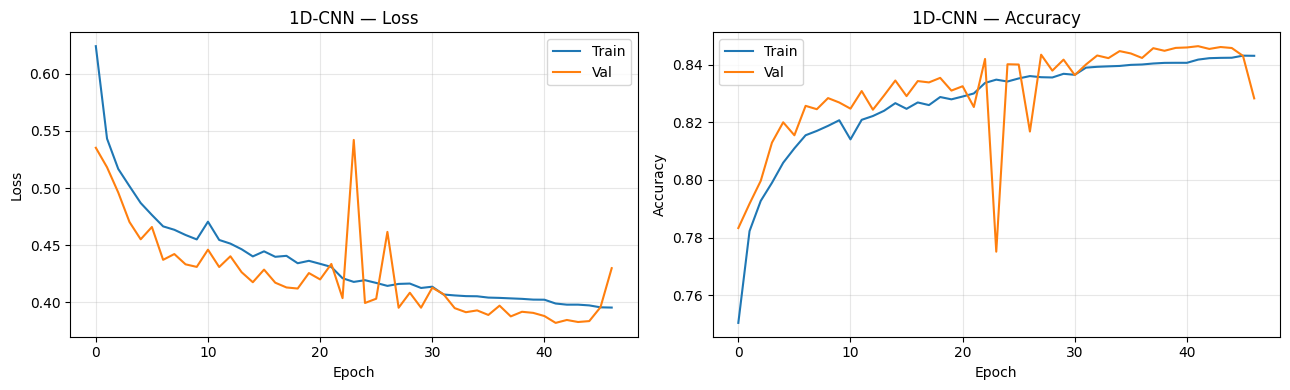


  1D-CNN
  Train Acc: 0.3639  |  Val Acc: 0.8465  |  Gap: -0.4826
  Val F1 (macro): 0.8340  |  Test F1 (macro): 0.8350
  Training time: 1024.4s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.8167    0.9632    0.8839    109819
  BruteForce     0.9999    0.9561    0.9775     26944
       Recon     0.8272    0.6344    0.7181     35456
    Spoofing     0.8576    0.6767    0.7565     48651

    accuracy                         0.8465    220870
   macro avg     0.8754    0.8076    0.8340    220870
weighted avg     0.8497    0.8465    0.8406    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.8156    0.9642    0.8837    109820
  BruteForce     1.0000    0.9580    0.9785     26943
       Recon     0.8359    0.6373    0.7232     35457
    Spoofing     0.8579    0.6735    0.7546     48650

    accuracy                         0.8470    220870
   macro avg     0.8774

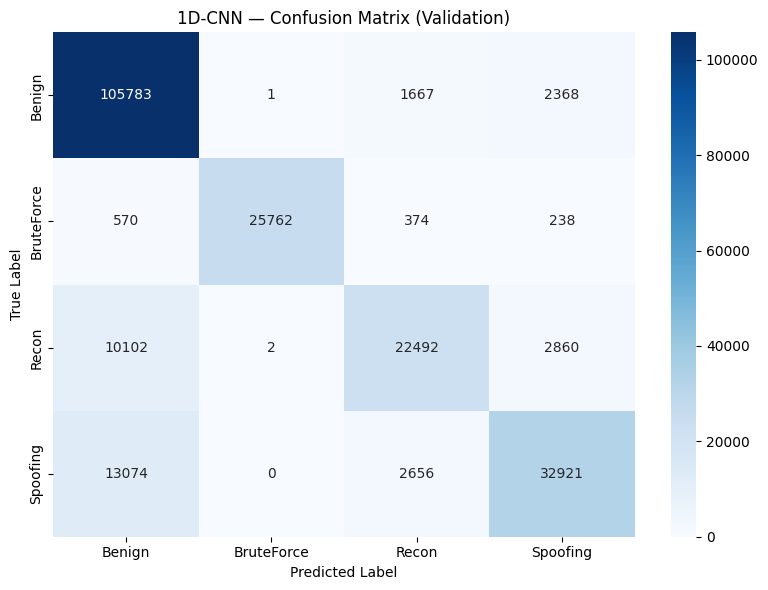

0.8339991616790287

In [16]:
# Retrain best 1D-CNN
bp = cnn_study.best_params
cnn_best = CNN1D(NUM_FEATURES, NUM_CLASSES, bp['n_filters'], bp['kernel_size'], bp['dropout'])

t0 = time.time()
cnn_history = train_pytorch_model(cnn_best, train_loader, val_loader,
                                   epochs=50, lr=bp['lr'], patience=5,
                                   weight_decay=bp['weight_decay'])
cnn_time = time.time() - t0

plot_training_curves(cnn_history['train_loss'], cnn_history['val_loss'],
                     cnn_history['train_acc'], cnn_history['val_acc'], '1D-CNN')

evaluate_model('1D-CNN', y_train_enc, predict_pytorch(cnn_best, train_loader),
               y_val_enc, predict_pytorch(cnn_best, val_loader),
               y_test_enc, predict_pytorch(cnn_best, test_loader), cnn_time)

# 9. LSTM (PyTorch)

In [17]:
class TabularLSTM(nn.Module):
    """Treats each feature as one timestep: input shape (batch, num_features, 1)."""
    def __init__(self, input_dim, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(-1)  # (batch, features, 1)
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])  # last hidden state


def lstm_objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 64, 256, step=64)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    model = TabularLSTM(NUM_FEATURES, hidden_size, num_layers, NUM_CLASSES, dropout)
    train_pytorch_model(model, train_loader, val_loader,
                        epochs=30, lr=lr, patience=5, weight_decay=wd)
    val_preds = predict_pytorch(model, val_loader)
    return f1_score(y_val_enc, val_preds, average='macro')

lstm_study = optuna.create_study(direction='maximize', study_name='LSTM')
lstm_study.optimize(lstm_objective, n_trials=20, show_progress_bar=True)
print(f"Best LSTM F1: {lstm_study.best_value:.4f}")
print(f"Best params: {lstm_study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   5  train_loss=0.4633  val_loss=0.4566  val_acc=0.8221
  Epoch  10  train_loss=0.4424  val_loss=0.4421  val_acc=0.8254
  Epoch  15  train_loss=0.4150  val_loss=0.4055  val_acc=0.8380
  Epoch  20  train_loss=0.4086  val_loss=0.4009  val_acc=0.8385
  Epoch  25  train_loss=0.4070  val_loss=0.3978  val_acc=0.8427
  Epoch  30  train_loss=0.3923  val_loss=0.3879  val_acc=0.8453


Best trial: 0. Best value: 0.835667:   5%|▌         | 1/20 [16:23<5:11:26, 983.49s/it]

  Epoch   5  train_loss=0.5848  val_loss=0.5695  val_acc=0.7662
  Epoch  10  train_loss=0.5335  val_loss=0.5153  val_acc=0.7942
  Epoch  15  train_loss=0.4913  val_loss=0.4864  val_acc=0.8087
  Epoch  20  train_loss=0.4570  val_loss=0.4514  val_acc=0.8211
  Epoch  25  train_loss=0.4372  val_loss=0.4263  val_acc=0.8302
  Epoch  30  train_loss=0.4265  val_loss=0.4228  val_acc=0.8327


Best trial: 0. Best value: 0.835667:  10%|█         | 2/20 [23:46<3:19:36, 665.38s/it]

...

Best trial: 2. Best value: 0.855568:  20%|██        | 4/20 [49:32<3:23:22, 762.67s/it]

  Epoch   5  train_loss=0.5802  val_loss=0.5562  val_acc=0.7753
  Epoch  10  train_loss=0.5457  val_loss=0.5283  val_acc=0.7872
  Epoch  15  train_loss=0.5200  val_loss=0.4985  val_acc=0.7993
  Epoch  20  train_loss=0.4837  val_loss=0.4579  val_acc=0.8183
  Epoch  25  train_loss=0.4592  val_loss=0.4402  val_acc=0.8258


Best trial: 2. Best value: 0.855568:  20%|██        | 4/20 [4:42:43<18:50:54, 4240.94s/it]

[W 2026-04-04 11:27:31,310] Trial 4 failed with parameters: {'hidden_size': 192, 'num_layers': 3, 'dropout': 0.4089423069663859, 'lr': 0.00011487394091535284, 'weight_decay': 1.6796611677509257e-06} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/dsalhmd/Documents/uni/level9/gp/smart_home_guard/.venv/lib64/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1461958/3085454076.py", line 28, in lstm_objective
    train_pytorch_model(model, train_loader, val_loader,
  File "/tmp/ipykernel_1461958/587264227.py", line 99, in train_pytorch_model
    total_loss += loss.item() * len(y_batch)
                  ^^^^^^^^^^^
KeyboardInterrupt
[W 2026-04-04 11:27:31,312] Trial 4 failed with value None.


KeyboardInterrupt: 

  Epoch   5  train_loss=0.4178  val_loss=0.4052  val_acc=0.8384
  Epoch  10  train_loss=0.3898  val_loss=0.3756  val_acc=0.8489
  Epoch  15  train_loss=0.3780  val_loss=0.3674  val_acc=0.8526
  Epoch  20  train_loss=0.3720  val_loss=0.3545  val_acc=0.8581
  Epoch  25  train_loss=0.3521  val_loss=0.3430  val_acc=0.8629
  Epoch  30  train_loss=0.3462  val_loss=0.3359  val_acc=0.8658
  Epoch  35  train_loss=0.3315  val_loss=0.3292  val_acc=0.8687
  Epoch  40  train_loss=0.3280  val_loss=0.3181  val_acc=0.8732
  Epoch  45  train_loss=0.3179  val_loss=0.3151  val_acc=0.8744
  Epoch  50  train_loss=0.3145  val_loss=0.3089  val_acc=0.8775


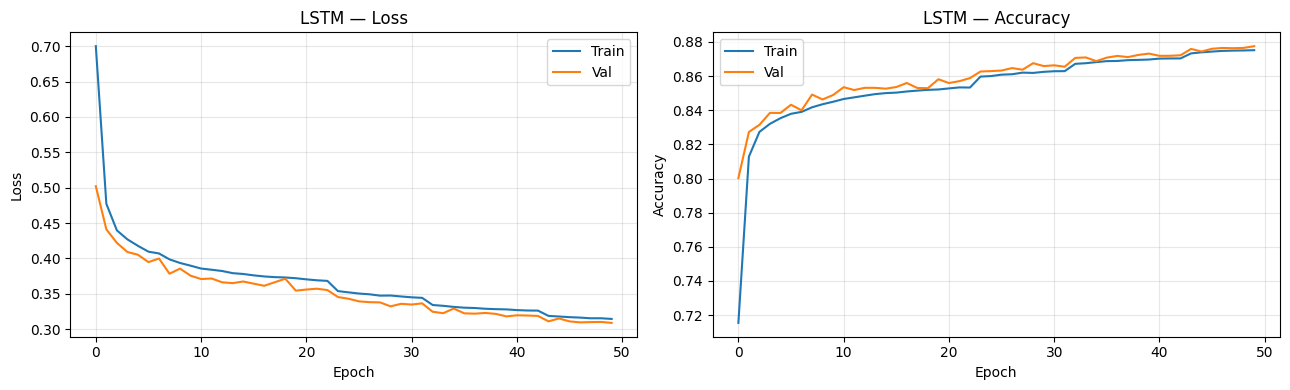


  LSTM
  Train Acc: 0.3513  |  Val Acc: 0.8775  |  Gap: -0.5262
  Val F1 (macro): 0.8689  |  Test F1 (macro): 0.8680
  Training time: 944.1s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.8691    0.9569    0.9109    109819
  BruteForce     0.9991    0.9597    0.9790     26944
       Recon     0.8079    0.7487    0.7772     35456
    Spoofing     0.8812    0.7466    0.8083     48651

    accuracy                         0.8775    220870
   macro avg     0.8893    0.8530    0.8689    220870
weighted avg     0.8778    0.8775    0.8752    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.8669    0.9569    0.9097    109820
  BruteForce     0.9992    0.9612    0.9798     26943
       Recon     0.8084    0.7467    0.7763     35457
    Spoofing     0.8818    0.7428    0.8064     48650

    accuracy                         0.8765    220870
   macro avg     0.8891   

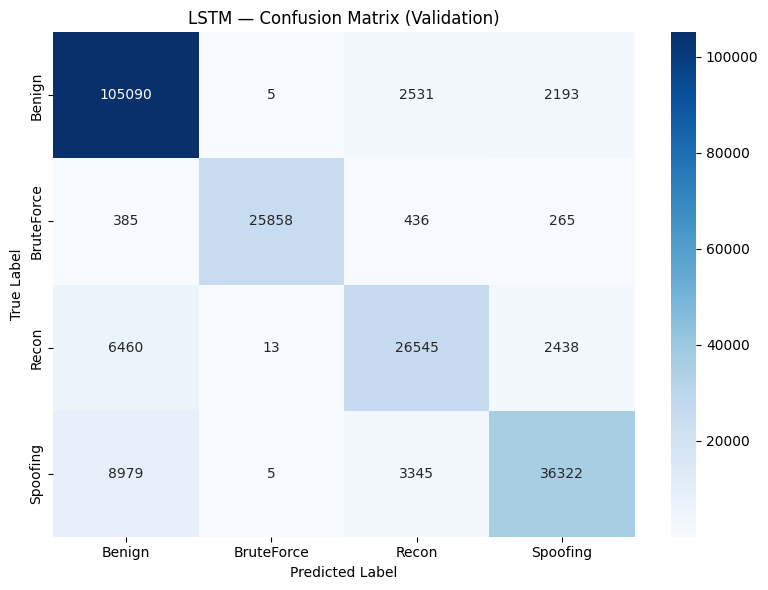

0.8688548440908649

In [18]:
# Retrain best LSTM
bp = lstm_study.best_params
lstm_best = TabularLSTM(NUM_FEATURES, bp['hidden_size'], bp['num_layers'],
                        NUM_CLASSES, bp['dropout'])

t0 = time.time()
lstm_history = train_pytorch_model(lstm_best, train_loader, val_loader,
                                    epochs=50, lr=bp['lr'], patience=5,
                                    weight_decay=bp['weight_decay'])
lstm_time = time.time() - t0

plot_training_curves(lstm_history['train_loss'], lstm_history['val_loss'],
                     lstm_history['train_acc'], lstm_history['val_acc'], 'LSTM')

evaluate_model('LSTM', y_train_enc, predict_pytorch(lstm_best, train_loader),
               y_val_enc, predict_pytorch(lstm_best, val_loader),
               y_test_enc, predict_pytorch(lstm_best, test_loader), lstm_time)

# 10. Transformer (PyTorch)

In [19]:
class TabularTransformer(nn.Module):
    """
    Encoder-only Transformer for tabular data.
    Each feature becomes a token: project scalar -> d_model embedding, add positional encoding,
    pass through TransformerEncoder layers, aggregate, classify.

    Args:
        input_dim:  number of features (sequence length)
        d_model:    embedding dimension per token
        nhead:      number of attention heads (must divide d_model)
        num_layers: number of TransformerEncoderLayer blocks
        num_classes: output classes
        dropout:    dropout rate
    """
    def __init__(self, input_dim, d_model, nhead, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.d_model = d_model
        self.input_proj = nn.Linear(1, d_model)
        # Learnable positional encoding for each feature position
        self.pos_embedding = nn.Parameter(torch.randn(1, input_dim, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(-1)              # (batch, num_features, 1)
        x = self.input_proj(x)           # (batch, num_features, d_model)
        x = x + self.pos_embedding       # add positional encoding
        x = self.encoder(x)              # (batch, num_features, d_model)
        x = x.mean(dim=1)               # mean pool across feature tokens → (batch, d_model)
        return self.classifier(x)        # (batch, num_classes)

In [20]:
def transformer_objective(trial):
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4, 8])
    # Ensure nhead divides d_model
    while d_model % nhead != 0:
        nhead = trial.suggest_categorical('nhead', [2, 4, 8])
    num_layers = trial.suggest_int('num_layers', 1, 4)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    model = TabularTransformer(NUM_FEATURES, d_model, nhead, num_layers,
                                NUM_CLASSES, dropout)
    train_pytorch_model(model, train_loader, val_loader,
                        epochs=30, lr=lr, patience=5, weight_decay=wd)
    val_preds = predict_pytorch(model, val_loader)
    return f1_score(y_val_enc, val_preds, average='macro')

tf_study = optuna.create_study(direction='maximize', study_name='Transformer')
tf_study.optimize(transformer_objective, n_trials=20, show_progress_bar=True)
print(f"Best Transformer F1: {tf_study.best_value:.4f}")
print(f"Best params: {tf_study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   5  train_loss=0.4640  val_loss=0.4882  val_acc=0.8120
  Epoch  10  train_loss=0.4280  val_loss=0.4450  val_acc=0.8270
  Epoch  15  train_loss=0.4075  val_loss=0.4753  val_acc=0.8242
  Early stopping at epoch 15


Best trial: 0. Best value: 0.812718:   5%|▌         | 1/20 [12:22<3:55:01, 742.17s/it]

  Epoch   5  train_loss=0.4157  val_loss=0.4570  val_acc=0.8251
  Epoch  10  train_loss=0.3764  val_loss=0.4006  val_acc=0.8393
  Epoch  15  train_loss=0.3617  val_loss=0.3759  val_acc=0.8483
  Epoch  20  train_loss=0.3452  val_loss=0.3625  val_acc=0.8556
  Epoch  25  train_loss=0.3359  val_loss=0.3576  val_acc=0.8560
  Epoch  30  train_loss=0.3306  val_loss=0.3648  val_acc=0.8543
  Early stopping at epoch 30


Best trial: 1. Best value: 0.84417:  10%|█         | 2/20 [55:25<9:07:35, 1825.33s/it]

...

Best trial: 1. Best value: 0.84417:  15%|█▌        | 3/20 [1:20:39<7:56:48, 1682.88s/it]

  Epoch   5  train_loss=0.4220  val_loss=0.4264  val_acc=0.8281
  Epoch  10  train_loss=0.3747  val_loss=0.3866  val_acc=0.8438
  Epoch  15  train_loss=0.3580  val_loss=0.3848  val_acc=0.8442
  Epoch  20  train_loss=0.3489  val_loss=0.3641  val_acc=0.8536
  Epoch  25  train_loss=0.3339  val_loss=0.3568  val_acc=0.8543


Best trial: 1. Best value: 0.84417:  15%|█▌        | 3/20 [2:07:57<12:05:03, 2559.02s/it]

[W 2026-04-04 13:51:32,537] Trial 3 failed with parameters: {'d_model': 128, 'nhead': 2, 'num_layers': 3, 'dropout': 0.2084950306810292, 'lr': 0.0010999356763902763, 'weight_decay': 1.1355742287591836e-05} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/dsalhmd/Documents/uni/level9/gp/smart_home_guard/.venv/lib64/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1461958/3323647483.py", line 14, in transformer_objective
    train_pytorch_model(model, train_loader, val_loader,
  File "/tmp/ipykernel_1461958/587264227.py", line 99, in train_pytorch_model
    total_loss += loss.item() * len(y_batch)
                  ^^^^^^^^^^^
KeyboardInterrupt
[W 2026-04-04 13:51:32,539] Trial 3 failed with value None.


KeyboardInterrupt: 

  Epoch   5  train_loss=0.4402  val_loss=0.5005  val_acc=0.8126
  Epoch  10  train_loss=0.4034  val_loss=0.5061  val_acc=0.8100
  Epoch  15  train_loss=0.3864  val_loss=0.4494  val_acc=0.8304
  Epoch  20  train_loss=0.3738  val_loss=0.4267  val_acc=0.8348
  Epoch  24  train_loss=0.3532  val_loss=0.4165  val_acc=0.8323
  Early stopping at epoch 24


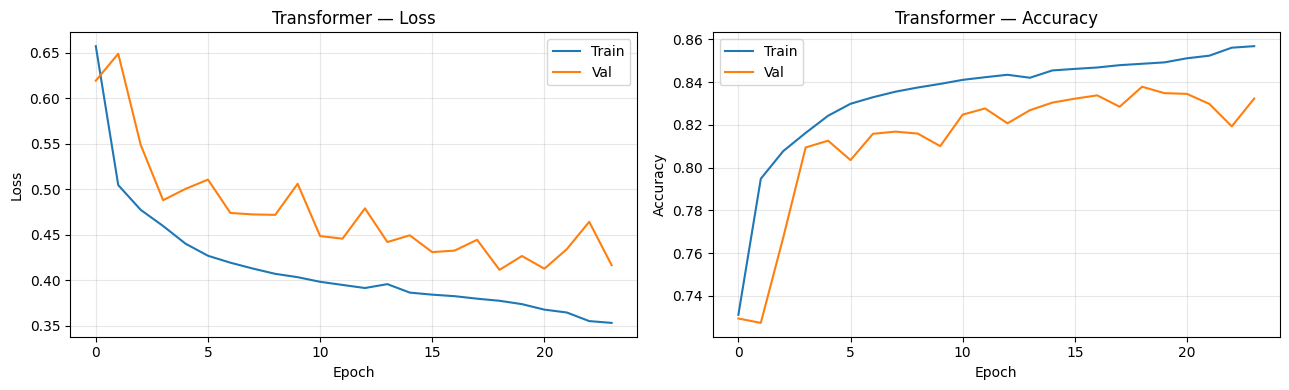


  Transformer
  Train Acc: 0.3596  |  Val Acc: 0.8379  |  Gap: -0.4782
  Val F1 (macro): 0.8249  |  Test F1 (macro): 0.8252
  Training time: 2206.0s

  Classification Report (Validation):
              precision    recall  f1-score   support

      Benign     0.8237    0.9443    0.8799    109819
  BruteForce     0.9939    0.9446    0.9686     26944
       Recon     0.7903    0.6407    0.7077     35456
    Spoofing     0.8170    0.6823    0.7436     48651

    accuracy                         0.8379    220870
   macro avg     0.8562    0.8029    0.8249    220870
weighted avg     0.8376    0.8379    0.8330    220870

  Classification Report (Test):
              precision    recall  f1-score   support

      Benign     0.8228    0.9451    0.8797    109820
  BruteForce     0.9928    0.9445    0.9681     26943
       Recon     0.7940    0.6461    0.7125     35457
    Spoofing     0.8179    0.6766    0.7406     48650

    accuracy                         0.8379    220870
   macro avg     0

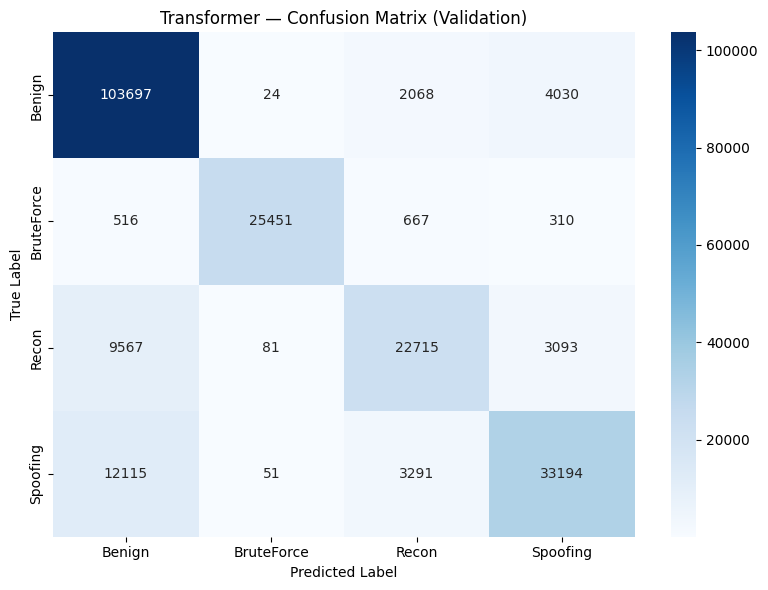

0.8249376684089488

In [21]:
# Retrain best Transformer
bp = tf_study.best_params
tf_best = TabularTransformer(NUM_FEATURES, bp['d_model'], bp['nhead'],
                              bp['num_layers'], NUM_CLASSES, bp['dropout'])

t0 = time.time()
tf_history = train_pytorch_model(tf_best, train_loader, val_loader,
                                  epochs=50, lr=bp['lr'], patience=5,
                                  weight_decay=bp['weight_decay'])
tf_time = time.time() - t0

plot_training_curves(tf_history['train_loss'], tf_history['val_loss'],
                     tf_history['train_acc'], tf_history['val_acc'], 'Transformer')

evaluate_model('Transformer', y_train_enc, predict_pytorch(tf_best, train_loader),
               y_val_enc, predict_pytorch(tf_best, val_loader),
               y_test_enc, predict_pytorch(tf_best, test_loader), tf_time)

# 11. Summary & Model Saving

In [22]:
# Summary table
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values('Test F1', ascending=False).reset_index(drop=True)
print("\n" + "=" * 75)
print("  MODEL BENCHMARK SUMMARY")
print("=" * 75)
print(summary_df.to_string(index=False))
print("=" * 75)

# Highlight best model
best = summary_df.iloc[0]
print(f"\nBest model: {best['Model']} (Test F1: {best['Test F1']:.4f})")


  MODEL BENCHMARK SUMMARY
      Model   Val F1  Test F1  Train-Val Gap  Time (s)
   LightGBM 0.943120 0.943681       0.024554     137.9
    XGBoost 0.942533 0.942911       0.035961      28.8
   CatBoost 0.937461 0.938146       0.012106      18.9
       LSTM 0.868855 0.868045      -0.526218     944.1
        MLP 0.864405 0.863130      -0.525601     477.2
     1D-CNN 0.833999 0.835020      -0.482563    1024.4
Transformer 0.824938 0.825205      -0.478208    2206.0

Best model: LightGBM (Test F1: 0.9437)


In [ ]:
# Save all models
os.makedirs('models', exist_ok=True)

# Shared preprocessing
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

# sklearn / boosting models
joblib.dump(rf_best, 'models/random_forest.pkl')
lgb_best.save_model('models/lightgbm.txt')
cb_best.save_model('models/catboost.cbm')
xgb_best.save_model('models/xgboost.json')

# PyTorch models
torch.save(mlp_best.state_dict(), 'models/mlp.pt')
torch.save(cnn_best.state_dict(), 'models/cnn1d.pt')
torch.save(lstm_best.state_dict(), 'models/lstm.pt')
torch.save(tf_best.state_dict(), 'models/transformer.pt')

# Save best hyperparameters for reproducibility
all_best_params = {
    'random_forest': rf_study.best_params,
    'lightgbm': lgb_study.best_params,
    'catboost': cb_study.best_params,
    'xgboost': xgb_study.best_params,
    'mlp': mlp_study.best_params,
    'cnn1d': cnn_study.best_params,
    'lstm': lstm_study.best_params,
    'transformer': tf_study.best_params,
}
joblib.dump(all_best_params, 'models/best_hyperparams.pkl')

print("All models saved to models/")
print("Files:", sorted(os.listdir('models')))

All models saved to models/
Files: ['best_hyperparams.pkl', 'catboost.cbm', 'cnn1d.pt', 'label_encoder.pkl', 'lightgbm.txt', 'lstm.pt', 'mlp.pt', 'scaler.pkl', 'transformer.pt', 'xgboost.json']
